In [ ]:
import numpy as np
import pandas as pd
timestamp = pd.date_range('2020-01-01', freq='d', periods=1286)
x = pd.read_csv('X_train.csv').drop(columns='Id')
y = pd.read_csv('y_train.csv')['Close'].values
x['Mean'] = x[['Open', 'High', 'Low']].mean(axis=1)
x['Median'] = x[['Open', 'High', 'Low']].median(axis=1)
x['std'] = x[['Open', 'High', 'Low']].std(axis=1)
x['std'] = np.log1p(x['std'])
x['Close'] = y
x['Target'] = (y - x['Mean'])/x['Mean']*100
x['Volume'] = np.log1p(x['Volume'])
x['timestamp'] = timestamp[:643]
x

,High,Low,Open,Volume,Mean,Median,std,Close,Target,timestamp
0,1528.699951,1518.000000,1518.099976,5.370638,1521.599976,1518.099976,1.966967,1524.500000,0.190590,2020-01-01
1,1552.699951,1530.099976,1530.099976,4.682131,1537.633301,1530.099976,2.642487,1549.199951,0.752237,2020-01-02
2,1580.000000,1560.400024,1580.000000,6.033086,1573.466675,1580.000000,2.510903,1566.199951,-0.461829,2020-01-03
3,1576.300049,1558.300049,1558.300049,3.871201,1564.300049,1558.300049,2.432938,1571.800049,0.479448,2020-01-04
4,1604.199951,1552.300049,1579.699951,5.468060,1578.733317,1579.699951,3.294482,1557.400024,-1.351292,2020-01-05
...,...,...,...,...,...,...,...,...,...,...
638,1709.699951,1701.099976,1705.400024,6.582025,1705.399984,1705.400024,1.667705,1702.400024,-0.175909,2021-09-30
639,1712.400024,1709.199951,1712.199951,5.579730,1711.266642,1712.199951,1.026973,1709.199951,-0.120770,2021-10-01
640,1714.400024,1706.099976,1712.300049,7.429521,1710.933350,1712.300049,1.670628,1710.000000,-0.054552,2021-10-02
641,1708.500000,1699.500000,1707.099976,4.875197,1705.033325,1707.099976,1.765220,1699.500000,-0.324529,2021-10-03


<Axes: >

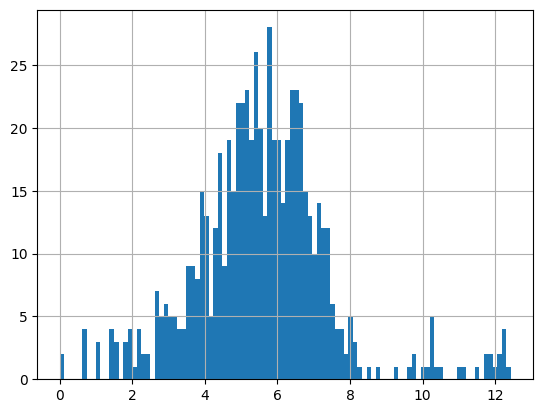

In [ ]:
x['Volume'].hist(bins=100)

In [ ]:
x_test = pd.read_csv('X_test.csv').drop(columns='Id')
x_test['Mean'] = x_test[['Open', 'High', 'Low']].mean(axis=1)
x_test['Median'] = x_test[['Open', 'High', 'Low']].median(axis=1)
x_test['std'] = x_test[['Open', 'High', 'Low']].std(axis=1)
x_test['std'] = np.log1p(x_test['std'])
x_test['Volume'] = np.log1p(x_test['Volume'])
x_test['timestamp'] = timestamp[643:]
x_test

,High,Low,Open,Volume,Mean,Median,std,timestamp
0,1735.000000,1713.000000,1713.300049,4.127134,1720.433350,1713.300049,2.611244,2021-10-05
1,1732.000000,1719.000000,1727.000000,4.219508,1726.000000,1727.000000,2.022532,2021-10-06
2,1718.000000,1717.699951,1718.000000,0.693147,1717.899984,1718.000000,0.159763,2021-10-07
3,1719.099976,1719.099976,1719.099976,11.883564,1719.099976,1719.099976,0.000000,2021-10-08
4,1755.000000,1732.000000,1732.300049,10.525058,1739.766683,1732.300049,2.652769,2021-10-09
...,...,...,...,...,...,...,...,...
638,2880.500000,2848.000000,2850.000000,8.416267,2859.500000,2850.000000,2.955639,2023-07-05
639,2871.699951,2836.300049,2865.199951,8.044626,2857.733317,2865.199951,2.987908,2023-07-06
640,2889.500000,2857.800049,2859.899902,7.508239,2869.066650,2859.899902,2.929962,2023-07-07
641,2916.100098,2863.800049,2864.199951,7.713338,2881.366699,2864.199951,3.436586,2023-07-08


In [ ]:
x["quarter"] = x["timestamp"].dt.quarter
x["quarter_sin"] = np.sin(2 * np.pi * x["quarter"] / 4)
x["quarter_cos"] = np.cos(2 * np.pi * x["quarter"] / 4)

x["hour"] = x["timestamp"].dt.hour
x["hour_sin"] = np.sin(2 * np.pi * x["hour"] / 24)
x["hour_cos"] = np.cos(2 * np.pi * x["hour"] / 24)

x["minute"] = x["timestamp"].dt.minute
x["minute_sin"] = np.sin(2 * np.pi * x["minute"] / 60)
x["minute_cos"] = np.cos(2 * np.pi * x["minute"] / 60)

x["day_of_year"] = x["timestamp"].dt.dayofyear
x["dayofyear_sin"] = np.sin(2 * np.pi * x["day_of_year"] / 366)
x["dayofyear_cos"] = np.cos(2 * np.pi * x["day_of_year"] / 366)

x["week_of_year"] = x["timestamp"].dt.isocalendar().week
x["week_sin"] = np.sin(2 * np.pi * x["week_of_year"] / 52)
x["week_cos"] = np.cos(2 * np.pi * x["week_of_year"] / 52)

# Day of month (1–31)
x["day_of_month"] = x["timestamp"].dt.day
x["dayofmonth_sin"] = np.sin(2 * np.pi * x["day_of_month"] / 31)
x["dayofmonth_cos"] = np.cos(2 * np.pi * x["day_of_month"] / 31)

x["month_of_year"] = x["timestamp"].dt.month
x["monthofyear_sin"] = np.sin(2 * np.pi * x["month_of_year"] / 12)
x["monthofyear_cos"] = np.cos(2 * np.pi * x["month_of_year"] / 12)

# Weekday (0=Mon, 6=Sun) and is_weekend
x["weekday"] = x["timestamp"].dt.weekday
x["weekday_sin"] = np.sin(2 * np.pi * x["weekday"] / 6)
x["weekday_cos"] = np.cos(2 * np.pi * x["weekday"] / 6)
x["is_weekend"] = x["weekday"].isin([5, 6]).astype(np.uint8)
x

,High,Low,Open,Volume,Mean,Median,std,Close,Target,timestamp,...,day_of_month,dayofmonth_sin,dayofmonth_cos,month_of_year,monthofyear_sin,monthofyear_cos,weekday,weekday_sin,weekday_cos,is_weekend
0,1528.699951,1518.000000,1518.099976,5.370638,1521.599976,1518.099976,1.966967,1524.500000,0.190590,2020-01-01,...,1,0.201299,0.979530,1,0.500000,8.660254e-01,2,8.660254e-01,-0.5,0
1,1552.699951,1530.099976,1530.099976,4.682131,1537.633301,1530.099976,2.642487,1549.199951,0.752237,2020-01-02,...,2,0.394356,0.918958,1,0.500000,8.660254e-01,3,1.224647e-16,-1.0,0
2,1580.000000,1560.400024,1580.000000,6.033086,1573.466675,1580.000000,2.510903,1566.199951,-0.461829,2020-01-03,...,3,0.571268,0.820763,1,0.500000,8.660254e-01,4,-8.660254e-01,-0.5,0
3,1576.300049,1558.300049,1558.300049,3.871201,1564.300049,1558.300049,2.432938,1571.800049,0.479448,2020-01-04,...,4,0.724793,0.688967,1,0.500000,8.660254e-01,5,-8.660254e-01,0.5,1
4,1604.199951,1552.300049,1579.699951,5.468060,1578.733317,1579.699951,3.294482,1557.400024,-1.351292,2020-01-05,...,5,0.848644,0.528964,1,0.500000,8.660254e-01,6,-2.449294e-16,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
638,1709.699951,1701.099976,1705.400024,6.582025,1705.399984,1705.400024,1.667705,1702.400024,-0.175909,2021-09-30,...,30,-0.201299,0.979530,9,-1.000000,-1.836970e-16,3,1.224647e-16,-1.0,0
639,1712.400024,1709.199951,1712.199951,5.579730,1711.266642,1712.199951,1.026973,1709.199951,-0.120770,2021-10-01,...,1,0.201299,0.979530,10,-0.866025,5.000000e-01,4,-8.660254e-01,-0.5,0
640,1714.400024,1706.099976,1712.300049,7.429521,1710.933350,1712.300049,1.670628,1710.000000,-0.054552,2021-10-02,...,2,0.394356,0.918958,10,-0.866025,5.000000e-01,5,-8.660254e-01,0.5,1
641,1708.500000,1699.500000,1707.099976,4.875197,1705.033325,1707.099976,1.765220,1699.500000,-0.324529,2021-10-03,...,3,0.571268,0.820763,10,-0.866025,5.000000e-01,6,-2.449294e-16,1.0,1


In [ ]:
x_test["quarter"] = x_test["timestamp"].dt.quarter
x_test["quarter_sin"] = np.sin(2 * np.pi * x_test["quarter"] / 4)
x_test["quarter_cos"] = np.cos(2 * np.pi * x_test["quarter"] / 4)

x_test["hour"] = x_test["timestamp"].dt.hour
x_test["hour_sin"] = np.sin(2 * np.pi * x_test["hour"] / 24)
x_test["hour_cos"] = np.cos(2 * np.pi * x_test["hour"] / 24)

x_test["minute"] = x_test["timestamp"].dt.minute
x_test["minute_sin"] = np.sin(2 * np.pi * x_test["minute"] / 60)
x_test["minute_cos"] = np.cos(2 * np.pi * x_test["minute"] / 60)

x_test["day_of_year"] = x_test["timestamp"].dt.dayofyear
x_test["dayofyear_sin"] = np.sin(2 * np.pi * x_test["day_of_year"] / 366)
x_test["dayofyear_cos"] = np.cos(2 * np.pi * x_test["day_of_year"] / 366)

x_test["week_of_year"] = x_test["timestamp"].dt.isocalendar().week
x_test["week_sin"] = np.sin(2 * np.pi * x_test["week_of_year"] / 52)
x_test["week_cos"] = np.cos(2 * np.pi * x_test["week_of_year"] / 52)

# Day of month (1–31)
x_test["day_of_month"] = x_test["timestamp"].dt.day
x_test["dayofmonth_sin"] = np.sin(2 * np.pi * x_test["day_of_month"] / 31)
x_test["dayofmonth_cos"] = np.cos(2 * np.pi * x_test["day_of_month"] / 31)

x_test["month_of_year"] = x_test["timestamp"].dt.month
x_test["monthofyear_sin"] = np.sin(2 * np.pi * x_test["month_of_year"] / 12)
x_test["monthofyear_cos"] = np.cos(2 * np.pi * x_test["month_of_year"] / 12)

# Weekday (0=Mon, 6=Sun) and is_weekend
x_test["weekday"] = x_test["timestamp"].dt.weekday
x_test["weekday_sin"] = np.sin(2 * np.pi * x_test["weekday"] / 6)
x_test["weekday_cos"] = np.cos(2 * np.pi * x_test["weekday"] / 6)
x_test["is_weekend"] = x_test["weekday"].isin([5, 6]).astype(np.uint8)
x_test

,High,Low,Open,Volume,Mean,Median,std,timestamp,quarter,quarter_sin,...,day_of_month,dayofmonth_sin,dayofmonth_cos,month_of_year,monthofyear_sin,monthofyear_cos,weekday,weekday_sin,weekday_cos,is_weekend
0,1735.000000,1713.000000,1713.300049,4.127134,1720.433350,1713.300049,2.611244,2021-10-05,4,-2.449294e-16,...,5,0.848644,0.528964,10,-0.866025,0.500000,1,8.660254e-01,0.5,0
1,1732.000000,1719.000000,1727.000000,4.219508,1726.000000,1727.000000,2.022532,2021-10-06,4,-2.449294e-16,...,6,0.937752,0.347305,10,-0.866025,0.500000,2,8.660254e-01,-0.5,0
2,1718.000000,1717.699951,1718.000000,0.693147,1717.899984,1718.000000,0.159763,2021-10-07,4,-2.449294e-16,...,7,0.988468,0.151428,10,-0.866025,0.500000,3,1.224647e-16,-1.0,0
3,1719.099976,1719.099976,1719.099976,11.883564,1719.099976,1719.099976,0.000000,2021-10-08,4,-2.449294e-16,...,8,0.998717,-0.050649,10,-0.866025,0.500000,4,-8.660254e-01,-0.5,0
4,1755.000000,1732.000000,1732.300049,10.525058,1739.766683,1732.300049,2.652769,2021-10-09,4,-2.449294e-16,...,9,0.968077,-0.250653,10,-0.866025,0.500000,5,-8.660254e-01,0.5,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
638,2880.500000,2848.000000,2850.000000,8.416267,2859.500000,2850.000000,2.955639,2023-07-05,3,-1.000000e+00,...,5,0.848644,0.528964,7,-0.500000,-0.866025,2,8.660254e-01,-0.5,0
639,2871.699951,2836.300049,2865.199951,8.044626,2857.733317,2865.199951,2.987908,2023-07-06,3,-1.000000e+00,...,6,0.937752,0.347305,7,-0.500000,-0.866025,3,1.224647e-16,-1.0,0
640,2889.500000,2857.800049,2859.899902,7.508239,2869.066650,2859.899902,2.929962,2023-07-07,3,-1.000000e+00,...,7,0.988468,0.151428,7,-0.500000,-0.866025,4,-8.660254e-01,-0.5,0
641,2916.100098,2863.800049,2864.199951,7.713338,2881.366699,2864.199951,3.436586,2023-07-08,3,-1.000000e+00,...,8,0.998717,-0.050649,7,-0.500000,-0.866025,5,-8.660254e-01,0.5,1


In [ ]:
features = ['High', 'Low', 'Open', 'Mean', 'Median']
for i in range(0,len(features)-1):
 for j in range(i+1,len(features)):
     x[f'{features[i]}_{features[j]}'] = (x[features[i]]-x[features[j]])/x[features[j]]*100
     x_test[f'{features[i]}_{features[j]}'] = (x_test[features[i]]-x_test[features[j]])/x_test[features[j]]*100
x

,High,Low,Open,Volume,Mean,Median,std,Close,Target,timestamp,...,High_Low,High_Open,High_Mean,High_Median,Low_Open,Low_Mean,Low_Median,Open_Mean,Open_Median,Mean_Median
0,1528.699951,1518.000000,1518.099976,5.370638,1521.599976,1518.099976,1.966967,1524.500000,0.190590,2020-01-01,...,0.704872,0.698240,0.466612,0.698240,-0.006586,-0.236591,-0.006586,-0.230021,0.0,0.230551
1,1552.699951,1530.099976,1530.099976,4.682131,1537.633301,1530.099976,2.642487,1549.199951,0.752237,2020-01-02,...,1.477026,1.477026,0.979860,1.477026,0.000000,-0.489930,0.000000,-0.489930,0.0,0.492342
2,1580.000000,1560.400024,1580.000000,6.033086,1573.466675,1580.000000,2.510903,1566.199951,-0.461829,2020-01-03,...,1.256087,0.000000,0.415219,0.000000,-1.240505,-0.830437,-1.240505,0.415219,0.0,-0.413502
3,1576.300049,1558.300049,1558.300049,3.871201,1564.300049,1558.300049,2.432938,1571.800049,0.479448,2020-01-04,...,1.155105,1.155105,0.767116,1.155105,0.000000,-0.383558,0.000000,-0.383558,0.0,0.385035
4,1604.199951,1552.300049,1579.699951,5.468060,1578.733317,1579.699951,3.294482,1557.400024,-1.351292,2020-01-05,...,3.343419,1.550927,1.613106,1.550927,-1.734500,-1.674334,-1.734500,0.061228,0.0,-0.061191
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
638,1709.699951,1701.099976,1705.400024,6.582025,1705.399984,1705.400024,1.667705,1702.400024,-0.175909,2021-09-30,...,0.505554,0.252136,0.252138,0.252136,-0.252143,-0.252141,-0.252143,0.000002,0.0,-0.000002
639,1712.400024,1709.199951,1712.199951,5.579730,1711.266642,1712.199951,1.026973,1709.199951,-0.120770,2021-10-01,...,0.187226,0.011685,0.066231,0.011685,-0.175213,-0.120770,-0.175213,0.054539,0.0,-0.054509
640,1714.400024,1706.099976,1712.300049,7.429521,1710.933350,1712.300049,1.670628,1710.000000,-0.054552,2021-10-02,...,0.486493,0.122641,0.202619,0.122641,-0.362090,-0.282499,-0.362090,0.079880,0.0,-0.079817
641,1708.500000,1699.500000,1707.099976,4.875197,1705.033325,1707.099976,1.765220,1699.500000,-0.324529,2021-10-03,...,0.529568,0.082012,0.203320,0.082012,-0.445198,-0.324529,-0.445198,0.121209,0.0,-0.121062


In [ ]:
x_test.columns

Index(['High', 'Low', 'Open', 'Volume', 'Mean', 'Median', 'std', 'timestamp',
       'quarter', 'quarter_sin', 'quarter_cos', 'hour', 'hour_sin', 'hour_cos',
       'minute', 'minute_sin', 'minute_cos', 'day_of_year', 'dayofyear_sin',
       'dayofyear_cos', 'week_of_year', 'week_sin', 'week_cos', 'day_of_month',
       'dayofmonth_sin', 'dayofmonth_cos', 'month_of_year', 'monthofyear_sin',
       'monthofyear_cos', 'weekday', 'weekday_sin', 'weekday_cos',
       'is_weekend', 'High_Low', 'High_Open', 'High_Mean', 'High_Median',
       'Low_Open', 'Low_Mean', 'Low_Median', 'Open_Mean', 'Open_Median',
       'Mean_Median'],
      dtype='object')

In [ ]:
features = ['Volume', 'std',
       'quarter', 'quarter_sin', 'quarter_cos', 'hour', 'hour_sin', 'hour_cos',
       'minute', 'minute_sin', 'minute_cos', 'day_of_year', 'dayofyear_sin',
       'dayofyear_cos', 'week_of_year', 'week_sin', 'week_cos', 'day_of_month',
       'dayofmonth_sin', 'dayofmonth_cos', 'month_of_year', 'monthofyear_sin',
       'monthofyear_cos', 'weekday', 'weekday_sin', 'weekday_cos',
       'is_weekend', 'High_Low', 'High_Open', 'High_Mean', 'High_Median',
       'Low_Open', 'Low_Mean', 'Low_Median', 'Open_Mean', 'Open_Median',
       'Mean_Median']

In [ ]:
from sklearn.ensemble import RandomForestRegressor
regr = RandomForestRegressor(n_estimators=100, max_depth=5, oob_score=True, random_state=0, n_jobs=-1)
regr.fit(x[features], x['Target'])
print("OOB Score (R^2):", regr.oob_score_)

OOB Score (R^2): 0.6721814197842197


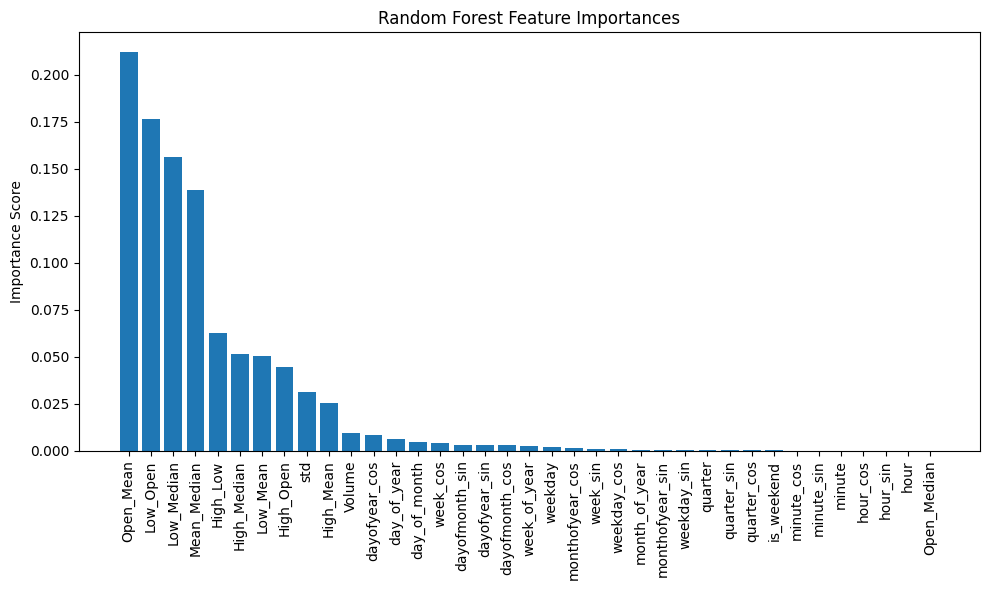

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Get feature importances
importances = regr.feature_importances_

# Create DataFrame for visualization
feat_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.bar(feat_importance_df['Feature'], feat_importance_df['Importance'])
plt.xticks(rotation=90)
plt.title("Random Forest Feature Importances")
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()


In [ ]:
prediction = regr.predict(x_test[features])
prediction = (1+prediction/100)
prediction

array([1.00462413, 0.99868309, 0.9998708 , 0.99985832, 1.00544476,
       1.00153773, 0.99934986, 1.00146078, 1.00292908, 1.00439444,
       0.99411341, 1.00376734, 1.00129392, 0.99672769, 0.99833748,
       1.00332995, 0.99418793, 0.99905806, 0.99820893, 0.99819192,
       0.99926446, 0.99748317, 1.00120144, 1.00144242, 0.99906775,
       0.99645233, 1.00181968, 0.99726276, 0.99825828, 0.99712961,
       1.00338474, 0.99900171, 1.00339631, 0.9972181 , 0.99928021,
       1.00006938, 0.99426972, 1.00023176, 0.99407257, 1.00041485,
       1.00152426, 1.00004424, 1.00372426, 1.0009153 , 0.99399298,
       1.00004424, 1.00005077, 1.00675399, 0.99719559, 1.00183304,
       1.01031145, 1.00799311, 0.9943114 , 0.99809479, 0.99665604,
       0.99396739, 1.00370606, 1.00119957, 0.99079438, 0.99451861,
       1.00146513, 1.00074739, 0.99842655, 1.00382942, 1.0033334 ,
       0.99732333, 0.99824791, 1.00398553, 1.00004424, 0.99428657,
       0.99839956, 1.00843234, 0.99879904, 0.99750099, 1.01145

In [ ]:
x_test['prediction'] = prediction
x_test['answer'] = x_test['prediction'] * x_test['Mean']
x_test

,High,Low,Open,Volume,Mean,Median,std,timestamp,quarter,quarter_sin,...,High_Mean,High_Median,Low_Open,Low_Mean,Low_Median,Open_Mean,Open_Median,Mean_Median,prediction,answer
0,1735.000000,1713.000000,1713.300049,4.127134,1720.433350,1713.300049,2.611244,2021-10-05,4,-2.449294e-16,...,0.846685,1.266559,-0.017513,-0.432063,-0.017513,-0.414622,0.0,0.416349,1.004624,1728.388853
1,1732.000000,1719.000000,1727.000000,4.219508,1726.000000,1727.000000,2.022532,2021-10-06,4,-2.449294e-16,...,0.347625,0.289519,-0.463231,-0.405562,-0.463231,0.057937,0.0,-0.057904,0.998683,1723.727005
2,1718.000000,1717.699951,1718.000000,0.693147,1717.899984,1718.000000,0.159763,2021-10-07,4,-2.449294e-16,...,0.005822,0.000000,-0.017465,-0.011644,-0.017465,0.005822,0.0,-0.005822,0.999871,1717.678026
3,1719.099976,1719.099976,1719.099976,11.883564,1719.099976,1719.099976,0.000000,2021-10-08,4,-2.449294e-16,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.999858,1718.856416
4,1755.000000,1732.000000,1732.300049,10.525058,1739.766683,1732.300049,2.652769,2021-10-09,4,-2.449294e-16,...,0.875595,1.310394,-0.017321,-0.446421,-0.017321,-0.429174,0.0,0.431024,1.005445,1749.239290
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
638,2880.500000,2848.000000,2850.000000,8.416267,2859.500000,2850.000000,2.955639,2023-07-05,3,-1.000000e+00,...,0.734394,1.070175,-0.070175,-0.402168,-0.070175,-0.332226,0.0,0.333333,1.003536,2869.611262
639,2871.699951,2836.300049,2865.199951,8.044626,2857.733317,2865.199951,2.987908,2023-07-06,3,-1.000000e+00,...,0.488731,0.226860,-1.008652,-0.750009,-1.008652,0.261278,0.0,-0.260597,0.996859,2848.758437
640,2889.500000,2857.800049,2859.899902,7.508239,2869.066650,2859.899902,2.929962,2023-07-07,3,-1.000000e+00,...,0.712195,1.035005,-0.073424,-0.392692,-0.073424,-0.319503,0.0,0.320527,1.003383,2878.771341
641,2916.100098,2863.800049,2864.199951,7.713338,2881.366699,2864.199951,3.436586,2023-07-08,3,-1.000000e+00,...,1.205449,1.812029,-0.013962,-0.609664,-0.013962,-0.595785,0.0,0.599356,1.006494,2900.077269


<Axes: >

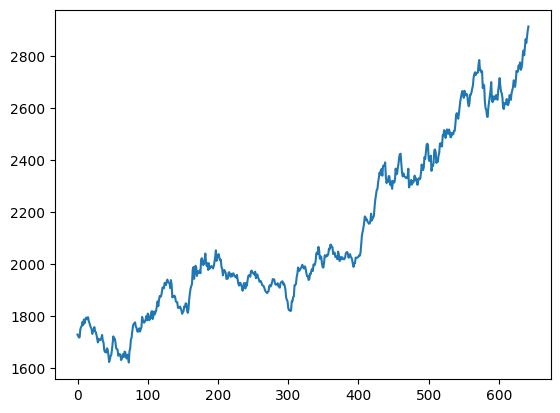

In [ ]:
submission = pd.read_csv('sample_submission.csv')
submission['Close'] = x_test['answer']#x_test['Mean']
submission.to_csv('submission.csv', index=False)
submission['Close'].plot()

In [ ]:
pwd

'/lustrefs/disk/project/ai901505-ai0005/earth/jupyterlab/PastPapers/DataScience/superai5-stock-price-prediction'